In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import matplotlib.gridspec as gridspec

# python font no dingbattes
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
#Change the working directory
import os
os.chdir('/Users/apoorvasingh/Desktop/MZB-new-analysis')

# open experimental data file 
df_new = pd.read_csv('data/New_data/new_data_MZB.csv')
df_new = df_new.sort_values(by='Age at BMT')

df_ont = pd.read_csv('data/New_data/ontogeny_counts.csv')


In [3]:
df_new['agebin'] = pd.cut(df_new['Age at BMT'], bins=[0, 70, 140],  labels=['<10 weeks', '>10 weeks'])
print(df_new)

                                    Unnamed: 0  Age at BMT  Age at S1K  \
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002_029.fcs          42         124   
13             20190312_SPLEEN_90d_002_019.fcs          51         141   
16           20190620_SPLEEN_22wks_005_021.fcs          58         212   
15           20190620_SPLEEN_22wks_004_020.fcs          65         219   
14            20190312_SPLEEN_117d_001_018.fcs          65         158   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
8        20181220_5wks_SPLEEN_CD1d_001

In [4]:
def P(t):
    theta_0 = 14.08
    nu = 0.25
    n = 1.8
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
 
# def b(M, b_param, K):
#     return b_param * (1 - (M / K))

def b(M, rho, M_stable, K):
    b_param = rho/ (1 - (M_stable/K))
    return b_param * (1 - (M / K))


 
# Define the ODE function
def ode_function(t, M, phi, rho, M_stable, d, K, P):
    dMdt = phi * P(t) + b(M, rho, M_stable, K) * M - d * M
    return np.array(dMdt)


# Define the parameters as array
phi = 0.0017
d = 0.035
rho = 0.14
Mstable = 2548755
K = 2748755

# phi =0.02 
# d=0.036
# b_param=0.088
# K= 2629715

t_ev = np.arange(11, 732, 0.1)



#Initial conditions at time t=40
M0 = [np.exp(9)]  # M0_log = 9
result = solve_ivp(ode_function, [10, 732], M0, t_eval=t_ev, args=(phi, rho, Mstable, d, K, P))
print(result.y.shape)



(1, 7210)


/var/folders/ps/wzpv12c53fsgbwcd_wt33b5r0000gn/T/ipykernel_77448/262449935.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


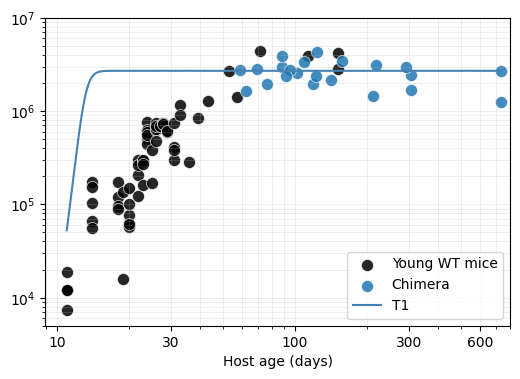

In [5]:
# Plot the Mz counts
fig = plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=75, color= 'black',label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=75, label='Chimera', legend=False,  linewidth=0.5)

# plt.plot(t_ev, np.mean(sol, axis=0), linestyle= 'dashed', color = 'steelblue', label = 'T1')
plt.plot(t_ev, result.y[0], color = 'steelblue', label = 'T1')

plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend(loc = 'lower right')
# plt.tight_layout()

#save the figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny_predictions.pdf', dpi=300)
plt.show()



In [ ]:
def chi_source(time, chi_est=0.85, nu=0.1, t0=10):
    if (time - t0) < 0:
        return 0.0
    else:
        return chi_est * (1 - np.exp(-nu * (time - t0)))
    
def eps_donor(time, m=-3.79e-5, c=0.99, t0=40):
    if (time - t0) < 0:
        return 0.0
    else:
        return m * (time - t0) + c
    
def eps_host(time, m=-1.7e-4, c=0.98, t0=40):
    if (time - t0) < 0:
         return 0.0
    else:
        return m * (time - t0) + c
    
def b(M, rho, M_stable,K):
    b_param = rho/ (1 - (M_stable/K))
    return b_param * (1 - (M / K))
    
def ode_sys(time, X, phi, rho, M_stable, d, K, ageATBMT):

    theta = 1298783
    beta = 3.5  
    
    dXdt = np.zeros(4)
        
    # Donor Ki67+ cells
    dXdt[0] = (phi * eps_donor(time) * chi_source(time - ageATBMT) * theta +
                   b((X[0] + X[1] + X[2] + X[3]), rho, M_stable, K) * (X[0] + 2*X[1]) - 
                   ((1/beta) + d) * X[0])
        
    # Donor Ki67- cells
    dXdt[1] = (phi * (1 - eps_donor(time)) * chi_source(time - ageATBMT) * theta +
                   (1/beta) * X[0] - 
                   (b((X[0] + X[1] + X[2] + X[3]), rho, M_stable, K) + d) * X[1])
        
    # Host Ki67+ cells
    dXdt[2] = (phi * eps_host(time) * (1 - chi_source(time - ageATBMT)) * theta +
                   b((X[0] + X[1] + X[2] + X[3]), rho, M_stable, K) * (X[2] + 2*X[3]) - 
                   ((1/beta) + d) * X[2])
        
    # Host Ki67- cells
    dXdt[3] = (phi * (1 - eps_host(time)) * (1 - chi_source(time - ageATBMT)) * theta +
                   (1/beta) * X[2] - 
                   (b((X[0] + X[1] + X[2] + X[3]), rho, M_stable, K) + d) * X[3])
        
    return dXdt

In [7]:
#Generate initial condition at time=40
N0 = solve_ivp(ode_function, [10, 40], M0, t_eval=[40], args=(phi, rho, Mstable, d, K, P))
kappa0 = 0.16
initial_cond = np.concatenate(([0.0, 0.0], N0.y[:, -1] * kappa0, N0.y[:, -1] * (1 - kappa0)))
print(initial_cond)

# Generate solution at earliest age at BMT, T=41
initial_tbmt = solve_ivp(ode_sys, [40, 41], initial_cond, t_eval=[41], args=(phi, rho, Mstable, d, K, 41))
print(initial_tbmt.y)

# Generate solution at earliest age at BMT, T=41
initial_tbmt2 = solve_ivp(ode_sys, [40, 74], initial_cond, t_eval=[74], args=(phi, rho, Mstable, d, K, 74))
print(initial_tbmt2.y)

#Add first and third intial_tbmt.y and second and fourth initial_tbmt.y
initial_tbmt1 = np.concatenate(([0.0, 0.0], initial_tbmt.y[0]+ initial_tbmt.y[2], initial_tbmt.y[1]+ initial_tbmt.y[3]))

#Add first and third intial_tbmt.y and second and fourth initial_tbmt.y
initial_tbmt3 = np.concatenate(([0.0, 0.0], initial_tbmt2.y[0]+ initial_tbmt2.y[2], initial_tbmt2.y[1]+ initial_tbmt2.y[3]))

#Solve the system of ODe for first age bin, t_ev = 52 to 750
t_ev1 = np.arange(52, 750, 1)
sol = solve_ivp(ode_sys, [41, 750], initial_tbmt1, t_eval=t_ev1, args=(phi, rho, Mstable, d, K, 41))
print(sol.y.shape)

#Solve the system of ODe for second age bin, t_ev = 88 to 750
t_ev2 = np.arange(88, 750, 1)
sol2 = solve_ivp(ode_sys, [74, 750], initial_tbmt3, t_eval=t_ev2, args=(phi, rho, Mstable, d, K, 74))
print(sol2.y.shape)

TypeError: b() takes 3 positional arguments but 4 were given

In [ ]:
# Define Nfd, Ki67 host and donor proportions 

#For agebin1
for i in range(len(t_ev1)):
    Total_Mz1 = sol.y[0, i] + sol.y[1, i] + sol.y[2, i] + sol.y[3, i]
    Nfd1 = (sol.y[0, i] + sol.y[1, i]) / (Total_Mz1 * chi_source(t_ev[i] - 41))
    host_ki_pred1= sol.y[2, i] / (sol.y[2, i] + sol.y[3, i])
    donor_ki_pred1 = sol.y[0, i] / (sol.y[0, i] + sol.y[1, i])
   #print(f"Time: {t_ev[i]}, Nfd_host: {Total_Mz}, Nfd_donor: {Nfd_donor}, Ki67_host: {Ki67_host}, Ki67_donor: {Ki67_donor}")

#For agebin2
for i in range(len(t_ev2)):
    Total_Mz2 = sol2.y[0, i] + sol2.y[1, i] + sol2.y[2, i] + sol2.y[3, i]
    Nfd2 = (sol2.y[0, i] + sol2.y[1, i]) / (Total_Mz2 * chi_source(t_ev2[i] - 74))
    host_ki_pred2= sol2.y[2, i] / (sol2.y[2, i] + sol2.y[3, i])
    donor_ki_pred2 = sol2.y[0, i] / (sol2.y[0, i] + sol2.y[1, i])
   #print(f"Time: {t_ev[i]}, Nfd_host: {Total_Mz}, Nfd_donor: {Nfd_donor}, Ki67_host: {Ki67_host}, Ki67_donor: {Ki67_donor}")

/tmp/ipykernel_1693112/3632412346.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  Nfd1 = (sol.y[0, i] + sol.y[1, i]) / (Total_Mz1 * chi_source(t_ev[i] - 41))


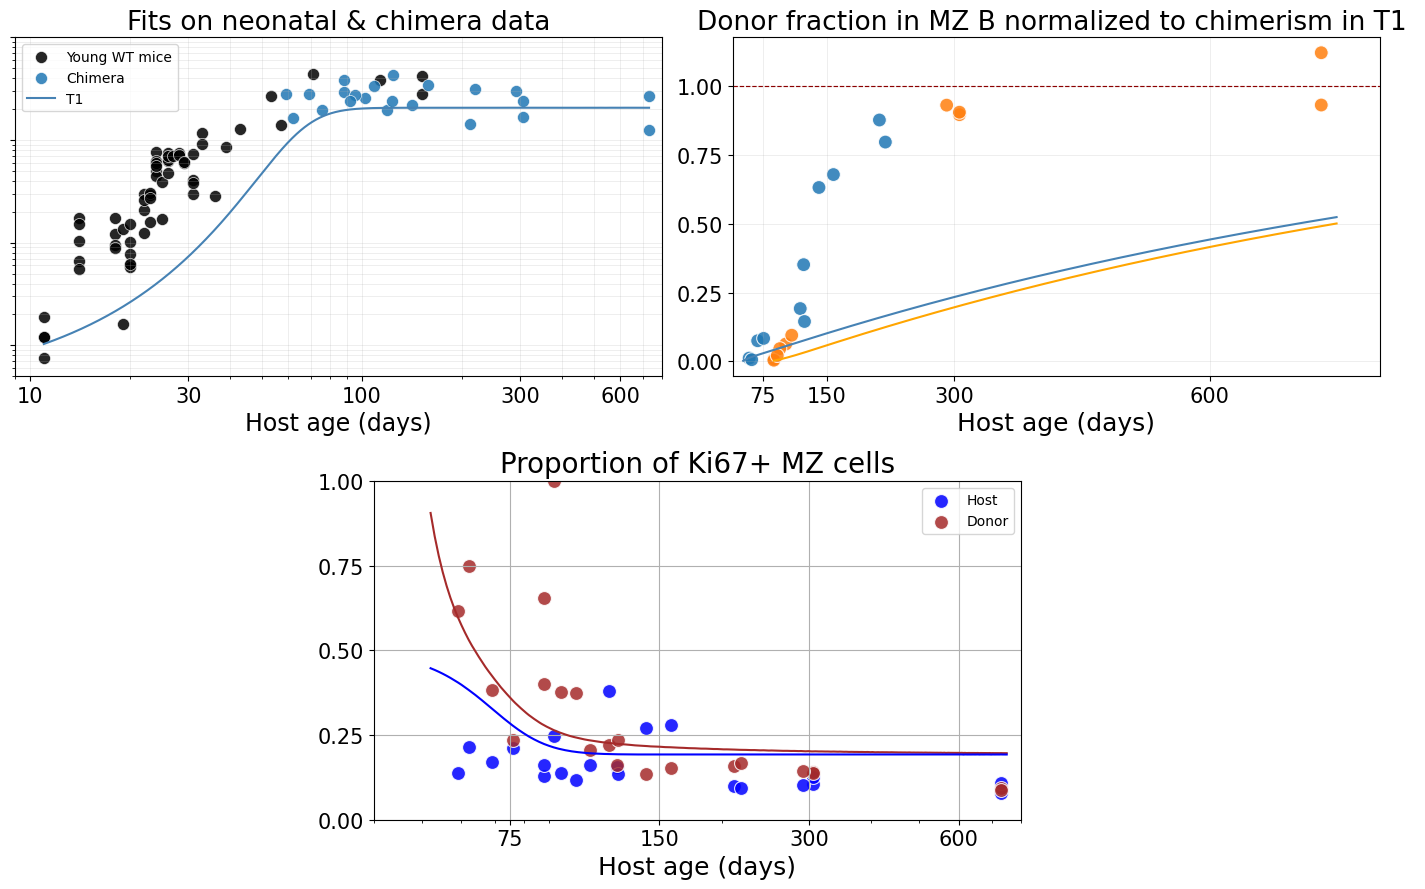

In [ ]:
#Plot all modalities for both age bins


# Create a figure with a custom grid layout
fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 4)  # Define a 2x4 grid

# Top row: Two plots
ax1 = fig.add_subplot(gs[0, 0:2])  # First plot spans columns 0 and 1
ax2 = fig.add_subplot(gs[0, 2:4])  # Second plot spans columns 2 and 3

# Bottom row: One centered plot
ax3 = fig.add_subplot(gs[1, 1:3])  # Centered plot spans columns 1 and 2

# Plot the Mz counts on ax1
sns.scatterplot(ax=ax1, data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=75, color='black', label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(ax=ax1, data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85, s=75, label='Chimera', legend=False, linewidth=0.5)

# plot model prediction on ax1
ax1.plot(t_ev, result.y[0], color='steelblue', label='T1')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(5 * 1e3, 1e7)
ax1.set_xlim(9, 800)
ax1.set_xticks([10, 30, 100, 300, 600])
ax1.set_xticklabels([10, 30, 100, 300, 600])
ax1.set_title('Fits on neonatal & chimera data', fontsize=19)
ax1.set_xlabel('Host age (days)', fontsize=17)
ax1.set_ylabel('')
ax1.set_yticklabels([])
ax1.tick_params(axis='both', labelsize=15)
ax1.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax1.legend()

# Compute time-series predictions for Nfd and Ki67 proportions (vectorized)
# For agebin1 (ageATBMT = 41)
chi1 = np.array([chi_source(t - 41) for t in t_ev1])
Total_Mz1 = sol.y.sum(axis=0)
Nfd1_arr = (sol.y[0, :] + sol.y[1, :]) / (Total_Mz1 * chi1)
donor_ki_pred1_arr = sol.y[0, :] / (sol.y[0, :] + sol.y[1, :])
host_ki_pred1_arr = sol.y[2, :] / (sol.y[2, :] + sol.y[3, :])

# For agebin2 (ageATBMT = 74)
chi2 = np.array([chi_source(t - 74) for t in t_ev2])
Total_Mz2 = sol2.y.sum(axis=0)
Nfd2_arr = (sol2.y[0, :] + sol2.y[1, :]) / (Total_Mz2 * chi2)
donor_ki_pred2_arr = sol2.y[0, :] / (sol2.y[0, :] + sol2.y[1, :])
host_ki_pred2_arr = sol2.y[2, :] / (sol2.y[2, :] + sol2.y[3, :])

# Plot normalized donor fraction on ax2
sns.scatterplot(ax=ax2, data=df_new, x='Age at S1K', y='Nfd_MZ', hue='agebin', alpha=0.85, s=100, legend=False)
ax2.plot(t_ev1, Nfd1_arr, color='steelblue')
ax2.plot(t_ev2, Nfd2_arr, color='orange')

ax2.set_xlim(40, 800)
ax2.set_xticks([75, 150, 300, 600])
ax2.set_xticklabels([75, 150, 300, 600])
ax2.set_ylabel('')
ax2.set_yticks(np.arange(0, 1.25, 0.25))
ax2.set_xlabel('Host age (days)', fontsize=18)
ax2.set_title('Donor fraction in MZ B normalized to chimerism in T1 ', fontsize=19)
ax2.axhline(y=1, color='darkred', linestyle='dashed', linewidth=0.85)
ax2.tick_params(axis='both', labelsize=15)
ax2.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)

# Plot Proportion of Ki67+ MZ cells on ax3
sns.scatterplot(ax=ax3, data=df_new, x='Age at S1K', y='frac_Ki67+_MZ_host', alpha=0.85, s=100, color='blue')
sns.scatterplot(ax=ax3, data=df_new, x='Age at S1K', y='frac_Ki67+_MZ_donor', alpha=0.85, s=100, color='brown')
ax3.plot(t_ev1, donor_ki_pred1_arr, color='brown')
ax3.plot(t_ev1, host_ki_pred1_arr, color='blue')

ax3.set_ylim(0, 1)
ax3.set_yticks(np.arange(0, 1.25, 0.25))
ax3.set_xscale('log')
ax3.set_xlim(40, 800)
ax3.set_xticks([75, 150, 300, 600])
ax3.set_xticklabels([75, 150, 300, 600])
ax3.tick_params(axis='both', labelsize=15)  # Set font size for both x and y-axis tick labels
ax3.set_ylabel('')
ax3.set_xlabel('Host age (days)', fontsize=18)
ax3.set_title('Proportion of Ki67+ MZ cells', fontsize=20)
ax3.grid(True, ls="solid")
ax3.legend(labels=['Host', 'Donor'])

plt.tight_layout()